### Angel Xavier
#### RollNo. 01
#### SE-AIML
#### Date: 11/03/2026

# Experiment 8: Clustering of Countries with World Bank API

## Part 1: Data Preprocessing

### Import libraries

In [43]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram,linkage

### Retrieve Data from api

In [44]:
def fetch_indicator(code, year="2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()

    data = {}

    for item in response[1]:
        country = item["country"]["value"]
        value = item["value"]
        if value is not None:
            data[country] = value

    return pd.Series(data, name=code)

In [45]:
gdp=fetch_indicator("NY.GDP.PCAP.CD")
pop=fetch_indicator("SP.POP.TOTL")
life=fetch_indicator("SP.DYN.LE00.IN")
lit=fetch_indicator("SE.ADT.LITR.ZS")

### Create Dataset and Clean the data

In [46]:
df=pd.concat([gdp,pop,life,lit],axis=1)
df.columns=["gdp","pop","life","lit"]
df.dropna(inplace=True)
df.head()

,gdp,pop,life,lit
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [47]:
df.tail()

,gdp,pop,life,lit
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


### Data Scaling

In [48]:
scalar=StandardScaler()
X_scaled=scalar.fit_transform(df)

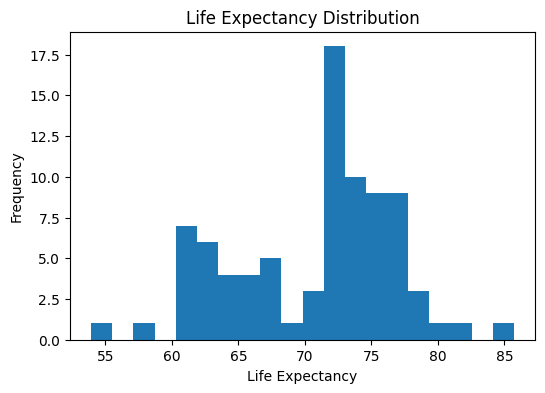

In [49]:
plt.figure(figsize=(6,4))
plt.hist(df["life"],bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.title("Life Expectancy Distribution")
plt.show()

## Part 2: Elbow method

k	WCSS
1 	 336.00000000000006
2 	 206.43717192603813
3 	 142.060283249676
4 	 122.4640064142117
5 	 68.7123470772603
6 	 56.09271840581914
7 	 51.08265517326419
8 	 41.70851027024396
9 	 31.213863029560212
10 	 27.04725098650772


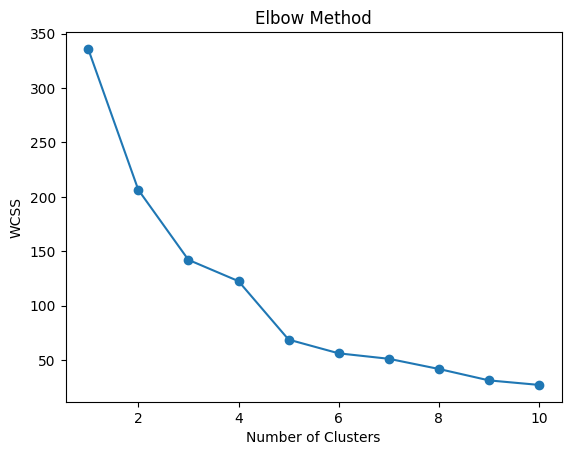

In [50]:
wcss=[]

for k in range(1,11):
    km = KMeans(n_clusters=k,random_state=0)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
  print(i+1,"\t",wcss[i])

plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()



## Part 3: K-Means Clustering

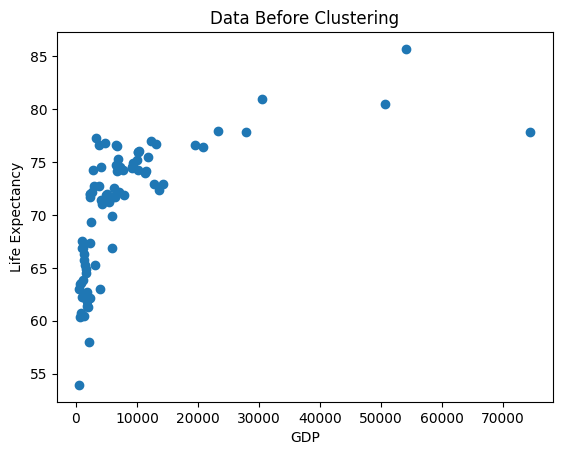

In [51]:
plt.scatter(df['gdp'],df['life'])
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Data Before Clustering")
plt.show()

In [52]:
kmeans=KMeans(n_clusters=3,random_state=0)
labels_km=kmeans.fit_predict(X_scaled)
df["KMeanscluster"]=labels_km

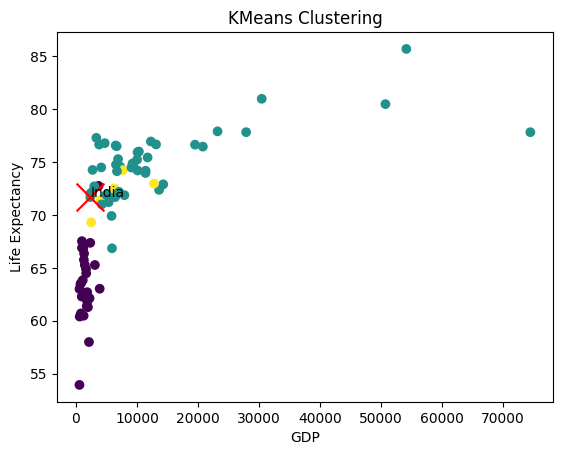

In [53]:
plt.scatter(df['gdp'],df['life'],c=labels_km)
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("KMeans Clustering")

india=df.loc["India"]
plt.scatter(india["gdp"],india["life"],s=400,marker="x",color="red")
plt.text(india["gdp"],india["life"],"India")
plt.show()

## Part 4: Agglomerative Clustering

In [54]:
hc=AgglomerativeClustering(n_clusters=3)
labels_hc=hc.fit_predict(X_scaled)

df["HierarchialCluster"]=labels_hc

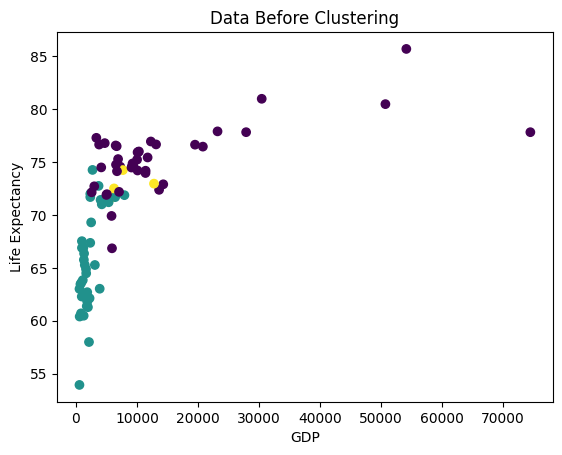

In [55]:
plt.scatter(df['gdp'],df['life'],c=labels_hc)
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Data Before Clustering")
plt.show()

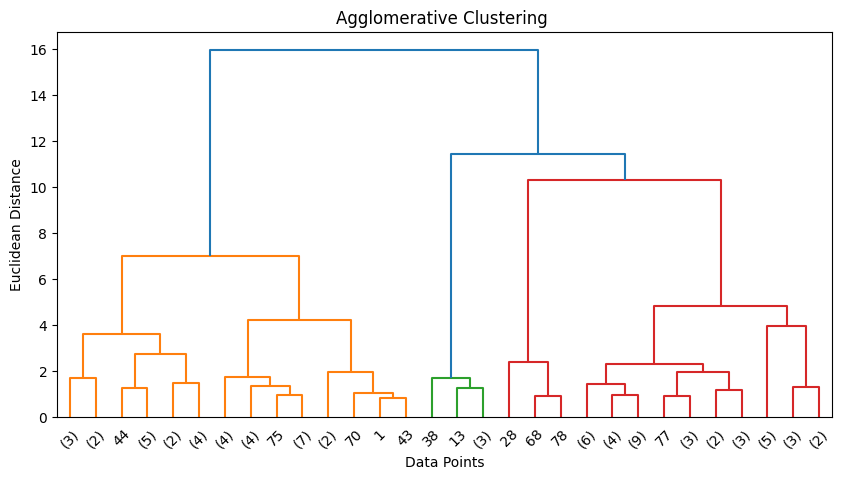

In [56]:
Linked=linkage(X_scaled,method="ward")
plt.figure(figsize=(10,5))
dendrogram(Linked,truncate_mode='lastp',p=30)
plt.title("Agglomerative Clustering ")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

## Part 5: Result

### Table 1

In [57]:
country_name="India"

result=df.loc[country_name]
print("Country:",country_name)
print("GDP:",result["gdp"])
print("Population:",result["pop"])
print("Life Expectancy:",result["life"])
print("Literacy Rate:",result["lit"])
print("KMeans Cluster:",result["KMeanscluster"])
print("Hierarchial Cluster:",result["HierarchialCluster"])


Country: India
GDP: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
KMeans Cluster: 1.0
Hierarchial Cluster: 1.0


In [58]:
country_name="North America"

result=df.loc[country_name]
print("Country:",country_name)
print("GDP:",result["gdp"])
print("Population:",result["pop"])
print("Life Expectancy:",result["life"])
print("Literacy Rate:",result["lit"])
print("KMeans Cluster:",result["KMeanscluster"])
print("Hierarchial Cluster:",result["HierarchialCluster"])


Country: North America
GDP: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398
KMeans Cluster: 1.0
Hierarchial Cluster: 0.0


In [59]:
country_name="Brazil"

result=df.loc[country_name]
print("Country:",country_name)
print("GDP:",result["gdp"])
print("Population:",result["pop"])
print("Life Expectancy:",result["life"])
print("Literacy Rate:",result["lit"])
print("KMeans Cluster:",result["KMeanscluster"])
print("Hierarchial Cluster:",result["HierarchialCluster"])


Country: Brazil
GDP: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348
KMeans Cluster: 1.0
Hierarchial Cluster: 0.0


In [60]:
country_name="Viet Nam"

result=df.loc[country_name]
print("Country:",country_name)
print("GDP:",result["gdp"])
print("Population:",result["pop"])
print("Life Expectancy:",result["life"])
print("Literacy Rate:",result["lit"])
print("KMeans Cluster:",result["KMeanscluster"])
print("Hierarchial Cluster:",result["HierarchialCluster"])


Country: Viet Nam
GDP: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418
KMeans Cluster: 1.0
Hierarchial Cluster: 0.0


In [61]:
country_name="Bahrain"

result=df.loc[country_name]
print("Country:",country_name)
print("GDP:",result["gdp"])
print("Population:",result["pop"])
print("Life Expectancy:",result["life"])
print("Literacy Rate:",result["lit"])
print("KMeans Cluster:",result["KMeanscluster"])
print("Hierarchial Cluster:",result["HierarchialCluster"])


Country: Bahrain
GDP: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
KMeans Cluster: 1.0
Hierarchial Cluster: 0.0


### Table 3

In [62]:
cluster_summary = df.groupby("KMeanscluster")[["gdp","pop","life","lit"]].mean()

print(cluster_summary)

                        gdp           pop       life        lit
KMeanscluster                                                  
0               1601.971896  4.854521e+08  63.478867  66.779721
1              12288.225626  4.669122e+08  74.753258  92.910908
2               6437.349751  5.501554e+09  71.975830  84.851687
